# Character-Level LSTM for Shakespeare Text Generation

In [ ]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 1 — Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Cell 2 — Download Shakespeare Dataset

In [2]:
path = tf.keras.utils.get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)

text = open(path, "rb").read().decode("utf-8")

print("Dataset downloaded successfully!")
print("Total characters:", len(text))

Dataset downloaded successfully!
Total characters: 1115394


## Cell 3 — View Dataset

In [3]:
print(text[:500])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## Cell 4 — Create Character Vocabulary

In [4]:
vocab = sorted(set(text))
vocab_size = len(vocab)

print("Vocabulary size:", vocab_size)
print("Characters:", vocab)

Vocabulary size: 65
Characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## Cell 5 — Convert Characters to Numbers

In [5]:
char_to_id = {char: i for i, char in enumerate(vocab)}
id_to_char = np.array(vocab)

encoded_text = np.array(
    [char_to_id[c] for c in text],
    dtype=np.int32
)

print("Original text:")
print(text[:50])
print("\nEncoded text:")
print(encoded_text[:50])

Original text:
First Citizen:
Before we proceed any further, hear

Encoded text:
[18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56 43  1 61 43
  1 54 56 53 41 43 43 42  1 39 52 63  1 44 59 56 58 46 43 56  6  1 46 43
 39 56]


## Cell 6 — Create Training Sequences

In [6]:
seq_length = 100

dataset = tf.data.Dataset.from_tensor_slices(encoded_text)

dataset = dataset.batch(
    seq_length + 1,
    drop_remainder=True
)

dataset = dataset.map(
    lambda x: (x[:-1], x[1:])
)

print("Sequences created successfully!")

Sequences created successfully!


## Cell 7 — Shuffle and Batch

In [7]:
BATCH_SIZE = 64

dataset = dataset.shuffle(
    10000
).batch(
    BATCH_SIZE,
    drop_remainder=True
)

print("Dataset ready for training!")

Dataset ready for training!


## Cell 8 — Build LSTM Model

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),
    tf.keras.layers.LSTM(
        128,
        return_sequences=True
    ),
    tf.keras.layers.Dense(
        vocab_size
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Cell 9 — Compile Model

In [9]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    )
)

print("Model compiled successfully!")

Model compiled successfully!


## Cell 10 — Train the Model

In [10]:
EPOCHS = 5

history = model.fit(
    dataset,
    epochs=EPOCHS
)

Epoch 1/5


c:\Users\rakul\OneDrive\Documents\Desktop\HCL_training1\rakul\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 2.8798
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - loss: 2.2831
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 2.1243
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - loss: 2.0169
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - loss: 1.9378


## Cell 11 — Plot Training Loss

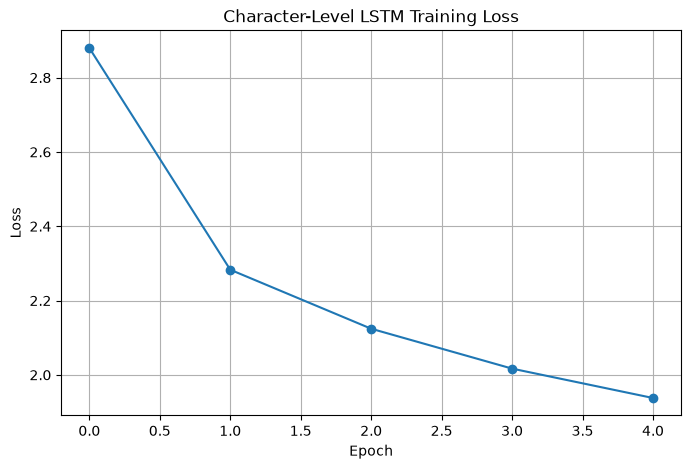

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    marker="o"
)
plt.title("Character-Level LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Cell 12 — Text Generation Function

In [12]:
def generate_text(start_text, length=300):

    generated = start_text

    for _ in range(length):

        input_text = generated[-seq_length:]

        input_ids = [
            char_to_id[c]
            for c in input_text
        ]

        input_ids = np.array(input_ids).reshape(1, -1)

        predictions = model.predict(
            input_ids,
            verbose=0
        )

        predictions = predictions[:, -1, :]

        predicted_id = tf.random.categorical(
            predictions,
            num_samples=1
        )[0, 0].numpy()

        generated += id_to_char[predicted_id]

    return generated

## Cell 13 — Generate Shakespeare-Like Text

In [13]:
generated_text = generate_text(
    "ROMEO: ",
    300
)

print("========== GENERATED TEXT ==========")
print(generated_text)

========== GENERATED TEXT ==========
ROMEO: lomes that dores-bat thie uppur'd ane it,
Whan so well fee he to matt anow,
Not comy no, come coond, your notcher or wrack tobloon:
Se of margresance.

GLELZAx:
Here owerlesend me,
O destent a quir in aw but thisteld.

WARWGRIO:
Sese grood of you of to'ldh;
Whis thake
I deskeld
Not shild grove, hagu
